### Khai báo thư viện và đường dẫn

#### Khởi tạo môi trường và Nạp ảnh mẫu

**Rationale:** Chuẩn bị công cụ xử lý và xác định ảnh thử nghiệm để kiểm chứng hiệu quả của từng kỹ thuật tiền xử lý trước khi áp dụng hàng loạt.

**Implementation:** 
* Sử dụng **OpenCV** để xử lý ma trận ảnh và **Matplotlib** để trực quan hóa.
* Tự động quét và lọc danh sách ảnh theo định dạng chuẩn (`.jpeg`, `.jpg`, `.png`) bằng thư viện `os`.
* Thiết lập đường dẫn tương đối giúp mã nguồn chạy ổn định trên nhiều thiết bị.

**Insights:** Việc tích hợp bước kiểm tra danh sách ảnh giúp quy trình nạp dữ liệu an toàn hơn, tránh lỗi chương trình khi thư mục trống.

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# File demo đã tải về (trong thư mục data/images/demo)
image_folder = '../data/images/demo' 
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpeg', '.jpg', '.png'))]
if len(image_files) > 0:
    sample_path = os.path.join(image_folder, image_files[0])
    print(f"Tìm thấy {len(image_files)} ảnh trong thư mục demo.")
    print(f"Đã chọn ảnh: {image_files[0]}")
else:
    print("Cảnh báo: Không tìm thấy file ảnh nào trong thư mục '../data/images/demo'!")

Tìm thấy 1 ảnh trong thư mục demo.
Đã chọn ảnh: person1001_bacteria_2932.jpeg


### Thực hiện Loading và Resizing

#### Hàm nạp và thay đổi kích thước

**Rationale:** Đưa các hình ảnh X-quang có kích thước khác nhau về một chuẩn duy nhất để mô hình có thể xử lý đồng nhất, đồng thời tối ưu hóa dung lượng bộ nhớ và tốc độ tính toán.

**Implementation:** 
* Xây dựng hàm chức năng `load_and_resize` để tái sử dụng. 
* Sử dụng phương pháp nội suy `INTER_AREA` trong OpenCV, đây là kỹ thuật tối ưu nhất khi thu nhỏ ảnh giúp tránh nhiễu và bảo toàn chi tiết tốt hơn.

**Insights:** Việc trả về đồng thời ảnh gốc và ảnh đã resize giúp nhóm dễ dàng thực hiện các phân tích so sánh về sự giữ lại thông tin và hiệu suất ở các bước sau.

In [2]:
def load_and_resize(image_path, target_size):
    """
    Thực hiện nạp ảnh và thay đổi kích thước.
    Output: ảnh gốc và ảnh đã resize.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    
    # Thực hiện resize
    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return img, resized_img

#### Trực quan hóa và phân tích sự đánh đổi

**Rationale:** Xác định kích thước ảnh tối ưu thông qua việc so sánh trực quan và đo lường dung lượng bộ nhớ chiếm dụng, nhằm cân bằng giữa độ nét y khoa và hiệu suất hệ thống.

**Implementation:**
* Sử dụng bố cục lưới (Grid) 2x3 để so sánh ảnh gốc với 4 kích thước mục tiêu: 64, 128, 224, và 512.
* Tính toán dung lượng RAM chiếm dụng thực tế (KB) của từng mảng dữ liệu ảnh bằng thuộc tính `.nbytes`.

**Insights:** Dung lượng bộ nhớ tăng theo cấp số nhân khi kích thước tăng. Kích thước 224x224 được nhận diện là "điểm cân bằng" lý tưởng: đủ sắc nét để chẩn đoán vùng thâm nhiễm phổi nhưng dung lượng RAM thấp hơn ảnh gốc hàng chục lần, giúp tăng tốc độ huấn luyện mô hình.

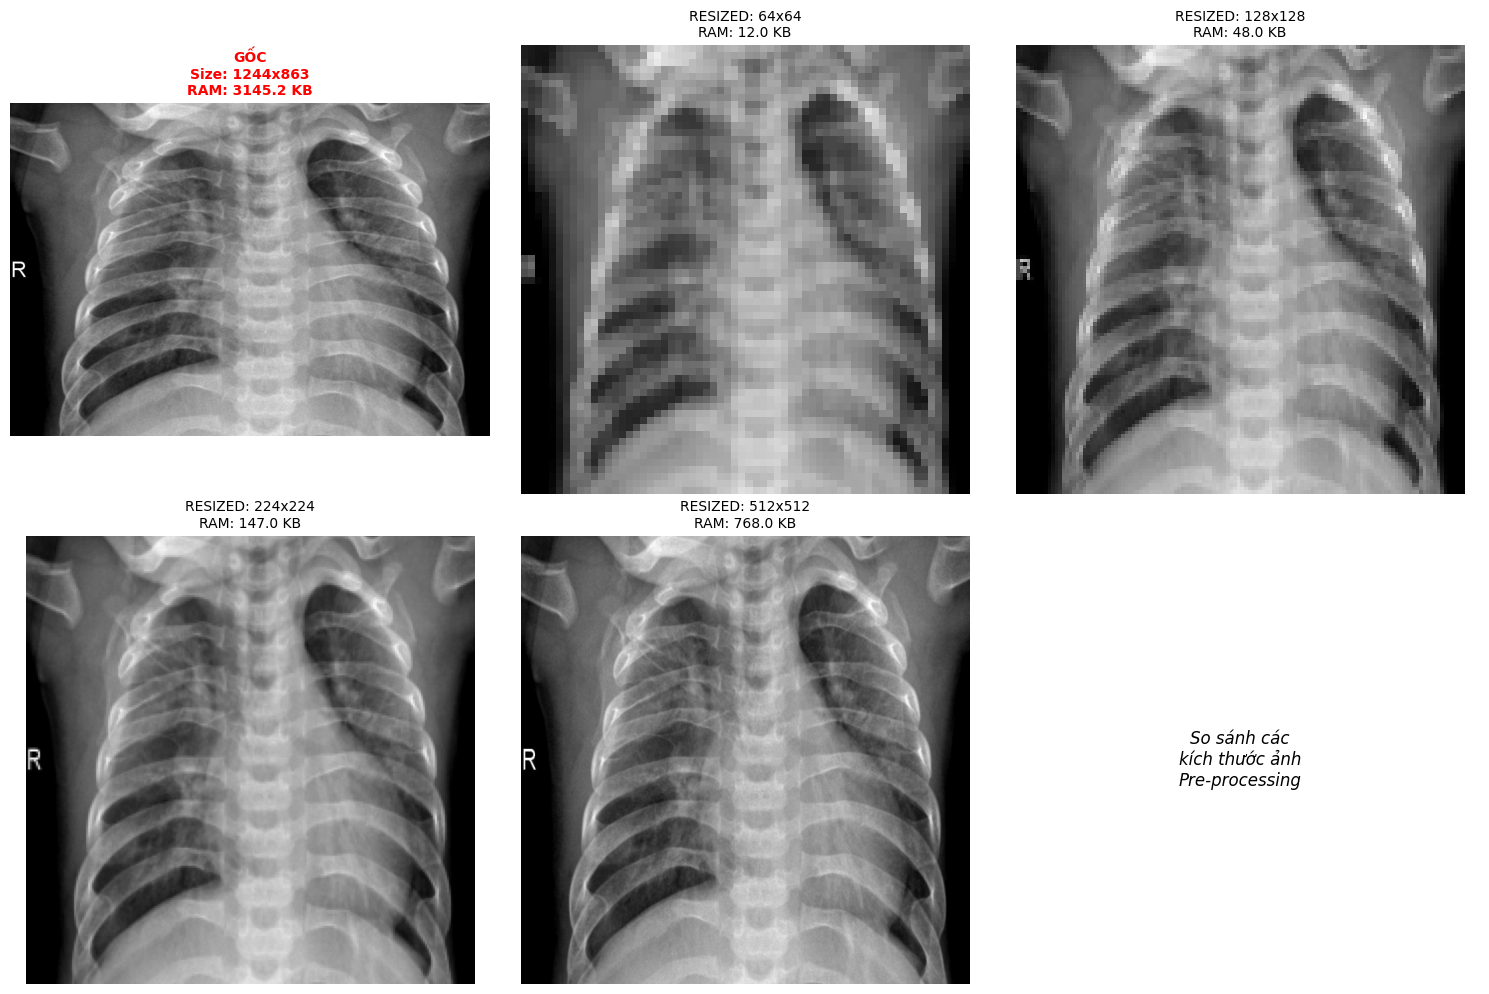

In [3]:
sizes = [(64, 64), (128, 128), (224, 224), (512, 512)]
# Lấy ảnh gốc để chuẩn bị hiển thị
original_img = cv2.imread(sample_path)
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Tạo khung hình (Figure) với bố cục lưới 2 hàng, 3 cột
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten() 

# 1. Hiển thị ảnh Gốc vào ô đầu tiên
axes[0].imshow(original_rgb)
axes[0].set_title(f"GỐC\nSize: {original_img.shape[1]}x{original_img.shape[0]}\nRAM: {original_img.nbytes/1024:.1f} KB", 
                  fontsize=10, fontweight='bold', color='red')
axes[0].axis('off')

# 2. Lặp qua các size và hiển thị vào các ô tiếp theo
for i, size in enumerate(sizes):
    _, resized = load_and_resize(sample_path, size)
    resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    
    ax = axes[i+1] 
    ax.imshow(resized_rgb)
    ax.set_title(f"RESIZED: {size[0]}x{size[1]}\nRAM: {resized.nbytes/1024:.1f} KB", fontsize=10)
    ax.axis('off')

# 3. Ô cuối cùng để ghi chú
axes[5].axis('off')
axes[5].text(0.5, 0.5, 'So sánh các\nkích thước ảnh\nPre-processing', 
             ha='center', va='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

### Grayscale Conversion

#### Hàm chuyển đổi sang thang độ xám (Grayscale Conversion)

**Rationale:** Ảnh X-quang y tế bản chất là ảnh đơn sắc. Việc chuyển đổi từ 3 kênh màu (RGB) về 1 kênh duy nhất giúp giảm 2/3 lượng dữ liệu dư thừa, tối ưu hóa tốc độ huấn luyện mô hình.

**Chi tiết triển khai (Implementation):** Xây dựng hàm `convert_to_grayscale` sử dụng không gian màu chuẩn `COLOR_BGR2GRAY` của OpenCV.

In [4]:
def convert_to_grayscale(img_bgr):
    """
    Chuyển đổi ảnh từ BGR sang Grayscale.
    """
    if img_bgr is None:
        return None
    
    gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return gray_img

**Phân tích sự giữ lại thông tin**

**Implementation:** 
* Thiết lập bố cục lưới 2x2 bằng Matplotlib để trình bày đồng thời hình ảnh trực quan và biểu đồ phân phối pixel.
* Sử dụng hàm `cv2.calcHist` để tính toán cường độ sáng (từ 0 đến 255) cho từng kênh màu.
* **Kỹ thuật tách nét:** Đối với ảnh RGB, nhóm sử dụng vòng lặp kết hợp các kiểu nét vẽ khác nhau (`linestyle`) và độ trong suốt (`alpha`). Kỹ thuật này cho phép quan sát rõ các đường đồ thị R, G, B vốn bị chồng khít hoàn toàn do bản chất dữ liệu X-quang là đơn sắc.
* Tính toán và hiển thị biểu đồ Histogram cho ảnh xám (đường nét đen) để đối chiếu cấu trúc phân bổ thông tin trước và sau khi xử lý.


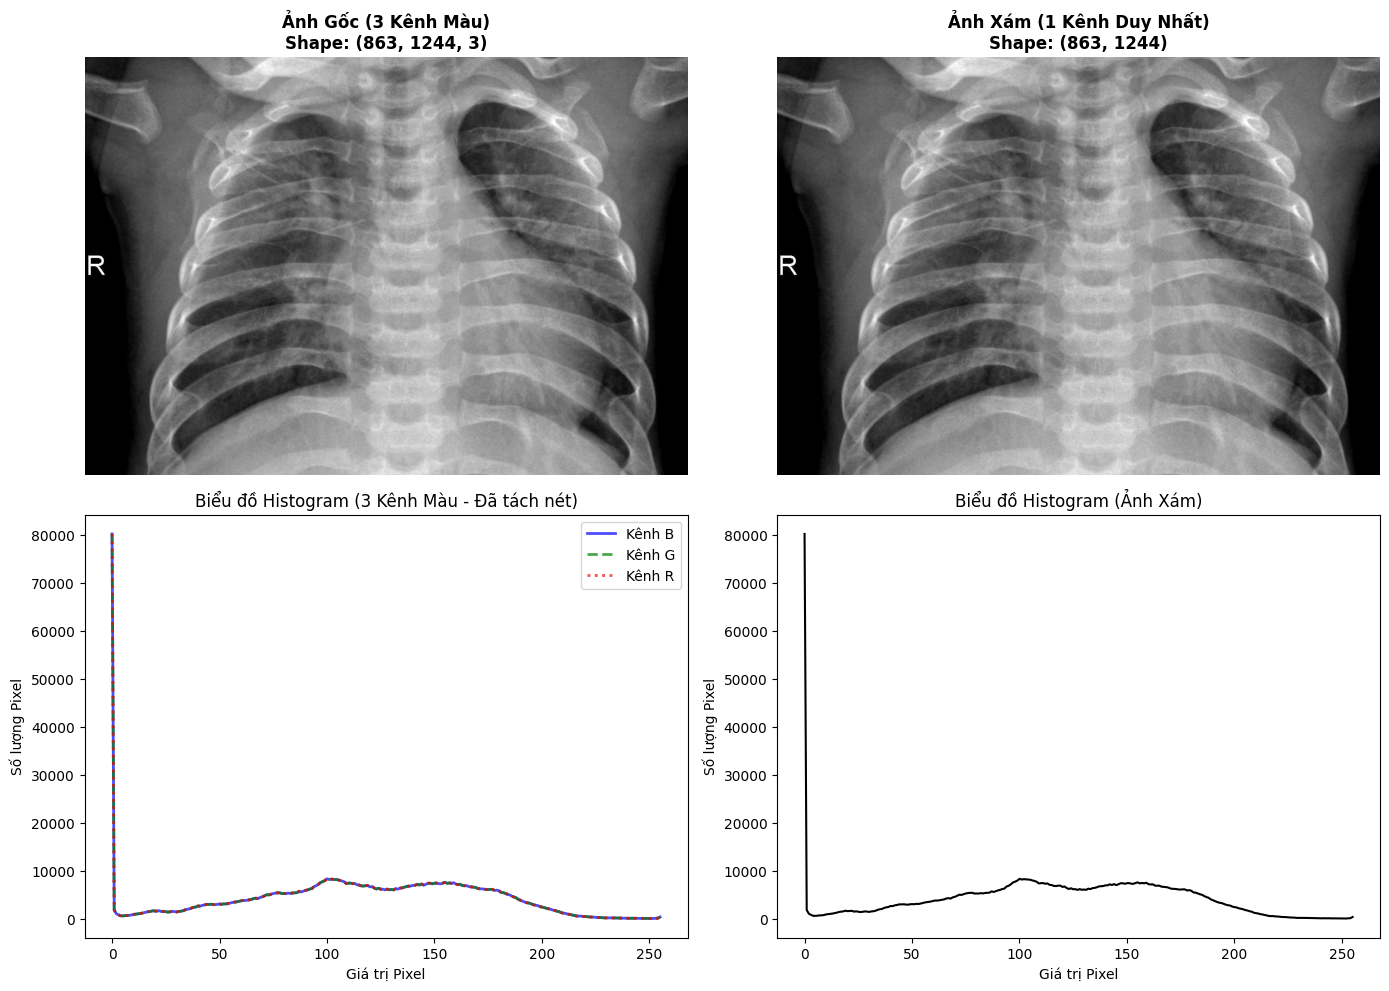

In [5]:
# 1. Thực hiện chuyển đổi
gray_img = convert_to_grayscale(original_img)

# 2. Trực quan hóa
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# So sánh hình ảnh
# Ảnh Gốc (RGB)
axes[0, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f"Ảnh Gốc (3 Kênh Màu)\nShape: {original_img.shape}", fontweight='bold')
axes[0, 0].axis('off')

# Ảnh Xám (Grayscale)
axes[0, 1].imshow(gray_img, cmap='gray')
axes[0, 1].set_title(f"Ảnh Xám (1 Kênh Duy Nhất)\nShape: {gray_img.shape}", fontweight='bold')
axes[0, 1].axis('off')

# Phân tích Histogram (Information Retention)

styles = ['-', '--', ':'] # Nét liền, nét đứt lớn, nét chấm điểm
colors = ('b', 'g', 'r')

for i, col in enumerate(colors):
    hist = cv2.calcHist([original_img], [i], None, [256], [0, 256])
    # Sử dụng linewidth và linestyle để phân biệt
    axes[1, 0].plot(hist, color=col, label=f'Kênh {col.upper()}', 
                    linestyle=styles[i], linewidth=2, alpha=0.7)

# Histogram ảnh RGB
axes[1, 0].set_title("Biểu đồ Histogram (3 Kênh Màu - Đã tách nét)")
axes[1, 0].set_xlabel("Giá trị Pixel")
axes[1, 0].set_ylabel("Số lượng Pixel")
axes[1, 0].legend()

# Histogram ảnh xám
hist_gray = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_gray, color='black')
axes[1, 1].set_title("Biểu đồ Histogram (Ảnh Xám)")
axes[1, 1].set_xlabel("Giá trị Pixel")
axes[1, 1].set_ylabel("Số lượng Pixel")

plt.tight_layout()
plt.show()

**Insights:** 
* Biểu đồ Histogram của 3 kênh R, G, B **chồng khít hoàn toàn**, minh chứng thông tin màu sắc trong tập dữ liệu Chest X-Ray là dư thừa. 
* Sau khi chuyển đổi, biểu đồ Histogram ảnh xám bảo toàn hoàn hảo hình dạng phân phối gốc, khẳng định kỹ thuật này giúp tối ưu dữ liệu mà **không làm mất đi thông tin chẩn đoán** y khoa cốt lõi.

### Normalization

### Hàm chuẩn hóa dữ liệu (Normalization & Standardization)

**Rationale:** Đưa giá trị pixel về thang đo nhỏ giúp thuật toán tối ưu (Gradient Descent) hội tụ nhanh hơn, đồng thời tránh việc các giá trị pixel lớn (0-255) làm bão hòa các hàm kích hoạt trong mô hình học sâu.

**Implementation:** Xây dựng hàm `apply_normalization` thực hiện 3 kỹ thuật: 
1. **Min-Max [0, 1]**: Ép dữ liệu vào khoảng 0 đến 1.
2. **Min-Max [-1, 1]**: Đưa dữ liệu về khoảng đối xứng quanh 0.
3. **Standardization (Z-score)**: Biến đổi dữ liệu có trung bình bằng 0 và độ lệch chuẩn bằng 1.

In [6]:
def apply_normalization(img_gray):
    """
    Thực hiện 3 kỹ thuật chuẩn hóa khác nhau.
    """
    # 1. Scaling to [0, 1]
    norm_01 = img_gray.astype(np.float32) / 255.0
    
    # 2. Scaling to [-1, 1]
    norm_minus1_1 = (img_gray.astype(np.float32) / 127.5) - 1.0
    
    # 3. Standardization (Zero mean, Unit variance)
    mean = np.mean(img_gray)
    std = np.std(img_gray)
    standardized = (img_gray.astype(np.float32) - mean) / std
    
    return norm_01, norm_minus1_1, standardized

**Phân tích Thống kê và Biểu đồ Phân phối**

**Implementation:** 
* Gọi hàm `apply_normalization` để trích xuất 3 phiên bản ảnh đã được chuẩn hóa.
* Khởi tạo cấu trúc dữ liệu **Dictionary** để thu thập 4 chỉ số thống kê cơ bản (Min, Max, Mean, Std Dev) từ dữ liệu gốc và các bản chuẩn hóa, sau đó chuyển thành **Pandas DataFrame** để hiển thị dạng bảng so sánh định lượng.
* Thiết lập bố cục lưới (Grid) 1x4 bằng Matplotlib. Sử dụng vòng lặp kết hợp phương thức `.flatten()` để trải phẳng ma trận ảnh thành mảng 1 chiều, phục vụ việc vẽ biểu đồ **Histogram** (50 bins) cho từng kỹ thuật.

BẢNG SO SÁNH THỐNG KÊ CHI TIẾT:


,Metric,Original (0-255),"Min-Max [0, 1]","Min-Max [-1, 1]",Standardization
0,Min,0.000000,0.000000,-1.000000,-1.997886e+00
1,Max,255.000000,1.000000,1.000000,2.551778e+00
2,Mean,111.977725,0.439128,-0.121743,-6.907058e-17
3,Std Dev,56.048093,0.219796,0.439593,1.000000e+00


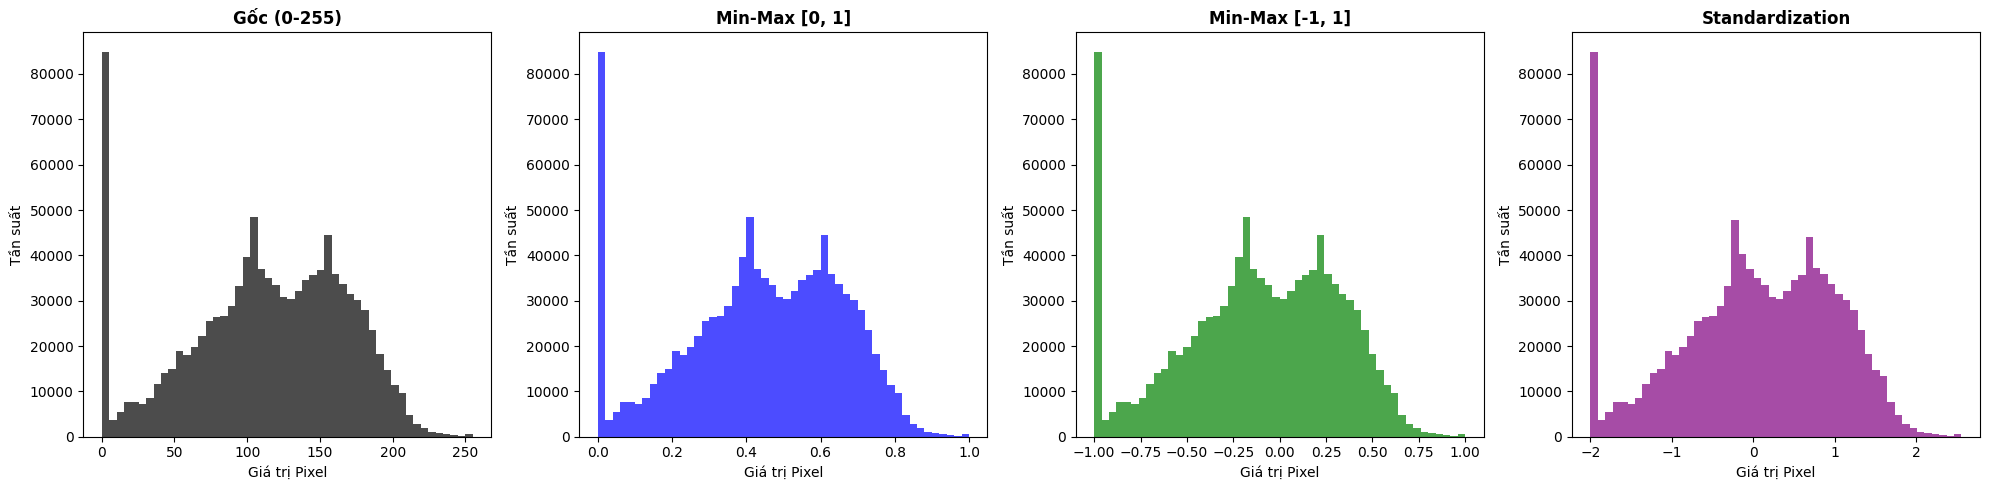

In [7]:
import pandas as pd 

# Thực thi chuẩn hóa trên ảnh xám đã có từ bước trước
norm_01, norm_m11, standardized = apply_normalization(gray_img)

# 1. Thu thập dữ liệu thống kê để phân tích
stats = {
    "Metric": ["Min", "Max", "Mean", "Std Dev"],
    "Original (0-255)": [gray_img.min(), gray_img.max(), gray_img.mean(), gray_img.std()],
    "Min-Max [0, 1]": [norm_01.min(), norm_01.max(), norm_01.mean(), norm_01.std()],
    "Min-Max [-1, 1]": [norm_m11.min(), norm_m11.max(), norm_m11.mean(), norm_m11.std()],
    "Standardization": [standardized.min(), standardized.max(), standardized.mean(), standardized.std()]
}
df_stats = pd.DataFrame(stats)
print("BẢNG SO SÁNH THỐNG KÊ CHI TIẾT:")
display(df_stats)

# 2. Trực quan hóa phân phối dữ liệu 
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

titles = ["Gốc (0-255)", "Min-Max [0, 1]", "Min-Max [-1, 1]", "Standardization"]
data_list = [gray_img, norm_01, norm_m11, standardized]
colors = ['black', 'blue', 'green', 'purple']

for i, data in enumerate(data_list):
    axes[i].hist(data.flatten(), bins=50, color=colors[i], alpha=0.7)
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_xlabel("Giá trị Pixel")
    axes[i].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

**Insights:** 
* **Kiểm chứng định lượng:** Bảng thống kê xác nhận kỹ thuật Standardization đưa Mean về mức cực nhỏ ($\approx 0$) và Std về đúng $1.0$, chứng minh tính chính xác của thuật toán.
* **Hiệu ứng trực quan:** Biểu đồ Standardization trông mượt và "đầy đặn" hơn do dữ liệu đã chuyển từ dạng số nguyên rời rạc (0-255) sang dạng số thực liên tục (float).
* **Ứng dụng:** Việc đưa dữ liệu về trọng tâm 0 giúp phân tách rõ rệt vùng phổi (giá trị âm) và vùng xương (giá trị dương), tạo điều kiện tối ưu cho mô hình học máy nhận diện đặc trưng.

### Edge Detection

#### Hàm kỹ thuật phát hiện cạnh

**Rationale:** Trích xuất các đặc trưng hình thái quan trọng như ranh giới xương và viền phổi, giúp mô hình tập trung vào cấu trúc hình học thay vì cường độ sáng.

**Implementation Details:** 
Xây dựng hàm `apply_edge_detection` tích hợp 3 phương pháp toán học khác nhau:
1. **Sobel:** Sử dụng hàm `cv2.Sobel` để tính đạo hàm bậc nhất theo trục X (ngang) và Y (dọc). Tham số `cv2.CV_64F` giúp giữ lại độ chính xác cho các giá trị đạo hàm âm. Kết quả cuối cùng được tổng hợp bằng hàm `cv2.magnitude` (căn bậc hai tổng bình phương X và Y).
2. **Prewitt:** Do OpenCV không hỗ trợ sẵn, nhóm tự định nghĩa 2 bộ lọc nhân chập (kernel) 3x3 bằng `np.array`. Hàm `cv2.filter2D` thực hiện phép nhân chập ma trận, và `cv2.addWeighted` dùng để hòa trộn kết quả hai trục với trọng số 50-50.
3. **Canny:** Quy trình 2 bước: Đầu tiên dùng `cv2.GaussianBlur` (size 5x5) để khử nhiễu hạt (noise) - bước này cực kỳ quan trọng cho ảnh y tế. Sau đó dùng `cv2.Canny` với ngưỡng kép (30 và 100) để lọc ra các đường biên thực sự.

In [8]:
def apply_edge_detection(img_gray):
    # 1. Sobel: Tính đạo hàm theo X và Y rồi kết hợp lại
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)
    
    # 2. Prewitt: Sử dụng bộ lọc nhân chập (kernel) tùy chỉnh
    kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    prewitt_x = cv2.filter2D(img_gray, -1, kernel_x)
    prewitt_y = cv2.filter2D(img_gray, -1, kernel_y)
    prewitt_combined = cv2.addWeighted(cv2.convertScaleAbs(prewitt_x), 0.5, 
                                       cv2.convertScaleAbs(prewitt_y), 0.5, 0)
    
    # 3. Canny: Thuật toán đa bước (bao gồm khử nhiễu và lọc biên)
    # Dùng thêm GaussianBlur trước Canny để giảm nhiễu tốt hơn
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    canny = cv2.Canny(blurred, threshold1=30, threshold2=100)
    
    return sobel_combined, prewitt_combined, canny

**Trực quan hóa để so sánh và đánh giá hiệu quả các thuật toán phát hiện cạnh**

**Implementation Details:** 
* Gọi hàm `apply_edge_detection` trên biến `gray_img` để nhận về 3 ma trận biên tương ứng.
* Sử dụng `plt.subplots(2, 2)` để tạo khung hiển thị lưới. 
* Thiết lập thuộc tính `cmap='gray'` cho tất cả các ô để đảm bảo hình ảnh được hiển thị đúng định dạng mức xám y tế.
* Sử dụng `axes.flatten()` (nếu cần) hoặc truy cập trực tiếp theo chỉ số hàng/cột để gán ảnh và đặt tiêu đề (`set_title`) mô tả đặc trưng của từng thuật toán.

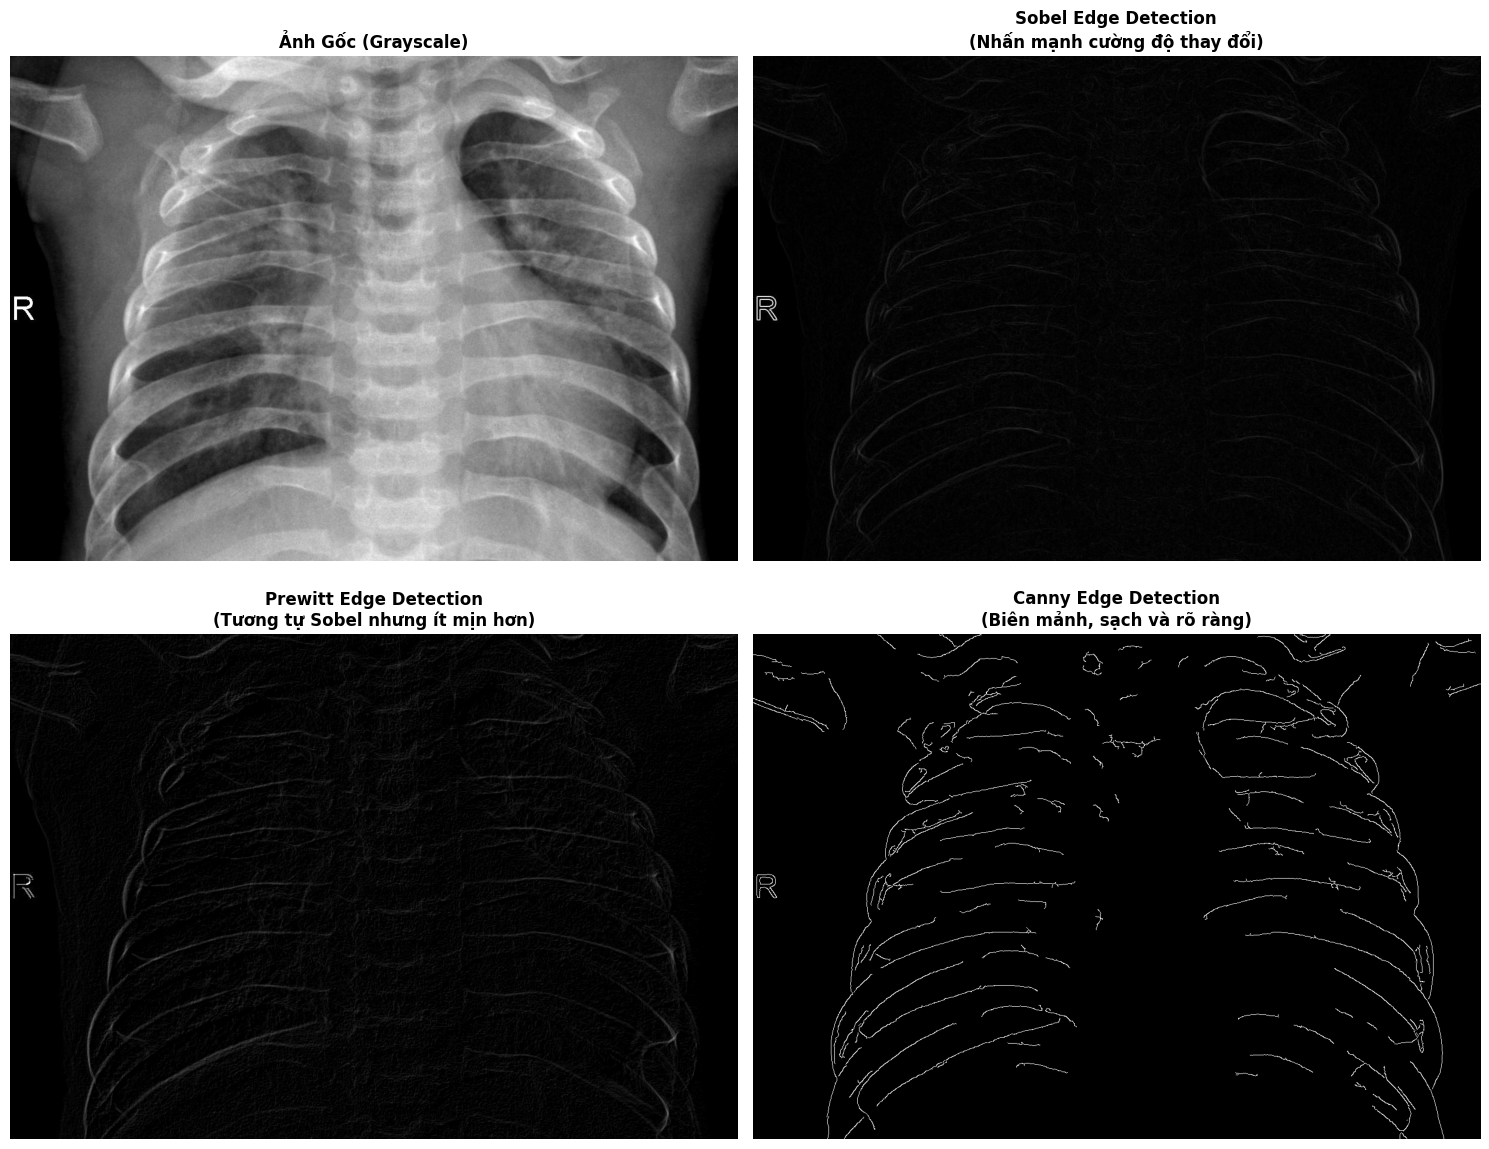

In [9]:
sobel, prewitt, canny = apply_edge_detection(gray_img)

# Trực quan hóa so sánh
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].imshow(gray_img, cmap='gray')
axes[0, 0].set_title("Ảnh Gốc (Grayscale)", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel, cmap='gray')
axes[0, 1].set_title("Sobel Edge Detection\n(Nhấn mạnh cường độ thay đổi)", fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(prewitt, cmap='gray')
axes[1, 0].set_title("Prewitt Edge Detection\n(Tương tự Sobel nhưng ít mịn hơn)", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(canny, cmap='gray')
axes[1, 1].set_title("Canny Edge Detection\n(Biên mảnh, sạch và rõ ràng)", fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Insights:** 
* **Sobel & Prewitt:** Tạo ra các đường biên khá dày và bị lẫn nhiều "nhiễu kết cấu" (texture noise) bên trong phổi. Hai phương pháp này hữu ích nếu cần phân tích sự thay đổi mật độ mô đột ngột.
* **Canny:** Mang lại kết quả tối ưu nhất với các đường biên mảnh (1 pixel), sạch nhiễu và liên tục. Thuật toán này bóc tách hoàn hảo khung xương sườn và vòm hoành.
* **Ý nghĩa:** Việc xác định rõ biên giới phổi là nền tảng cho kỹ thuật chẩn đoán dấu hiệu "Silhouette sign" (mất đường biên) - một chỉ số sống còn trong nhận diện vùng viêm phổi.

### Thực hiện Tiền xử lý hàng loạt (Batch Processing) trên tập dữ liệu Test

Dựa trên đặc thù của dữ liệu ảnh y tế (Chest X-Ray), nhóm quyết định áp dụng chuỗi xử lý sau:
1. **Loading & Resizing (224x224):** Đảm bảo tính đồng nhất về kích thước cho mô hình.
2. **Grayscale Conversion:** Loại bỏ 2/3 dữ liệu dư thừa về màu sắc, giữ lại 100% thông tin cường độ sáng cần thiết để chẩn đoán.
3. **Standardization (Z-score):** Kỹ thuật quan trọng nhất để đưa mọi hình ảnh về cùng một trạng thái thống kê, giúp triệt tiêu sự khác biệt về độ sáng/tối do các thiết bị chụp khác nhau tạo ra.

**Rationale:** 
Trong thực tế khai thác dữ liệu, việc xử lý từng ảnh đơn lẻ không hiệu quả. Nhóm xây dựng một quy trình tự động hóa (Pipeline) để áp dụng đồng nhất các kỹ thuật đã thử nghiệm lên toàn bộ tập dữ liệu `test`. Việc này đảm bảo tính khách quan và sẵn sàng dữ liệu cho các mô hình học sâu (Deep Learning).

**Implementation Details:**
Hàm `batch_processing` được thiết kế để thực hiện chuỗi thao tác khép kín:
1. **Duyệt thư mục hệ thống:** Sử dụng vòng lặp để quét qua hai nhãn dữ liệu y tế là `NORMAL` (Bình thường) và `PNEUMONIA` (Viêm phổi).
2. **Tái sử dụng Module (Code Reusability):** Thay vì viết lại logic, hàm gọi trực tiếp các hàm chức năng đã định nghĩa ở phần trước:
   * `load_and_resize`: Nạp và chuẩn hóa kích thước về 224x224.
   * `convert_to_grayscale`: Chuyển về ảnh xám để tối ưu bộ nhớ.
   * `apply_normalization`: Thực hiện chuẩn hóa Z-score (Standardization).
3. **Đo lường hiệu quả tài nguyên:** 
   * Sử dụng thư viện `time` để tính toán tổng thời gian thực thi của hệ thống.
   * Tính toán dung lượng RAM tiết kiệm được bằng cách lấy hiệu số `nbytes` giữa ảnh gốc và ảnh đã tiền xử lý.
4. **Cơ chế lưu mẫu (Sampling):** Sử dụng danh sách `sample_images` để giữ lại một số lượng nhỏ cặp ảnh (Gốc và Xử lý) phục vụ cho việc đối chiếu trực quan ở bước sau mà không làm tràn bộ nhớ RAM.

**Nhận xét (Insights):** 
Việc xây dựng hàm theo hướng module giúp mã nguồn gọn gàng và dễ bảo trì. Kết quả trả về dưới dạng **Pandas DataFrame** giúp nhóm dễ dàng thực hiện các thống kê mô tả (Mean, Std) trên quy mô lớn, từ đó đánh giá được mức độ ổn định của dữ liệu sau chuẩn hóa trên toàn bộ tập `test`.

In [10]:
import time
import os
import pandas as pd
import numpy as np

def batch_processing(base_path, target_size=(224, 224), num_to_save=5):
    results = []
    sample_images = [] 
    start_time = time.time()
    categories = ['NORMAL', 'PNEUMONIA']

    for category in categories:
        folder_path = os.path.join(base_path, category)
        if not os.path.exists(folder_path): continue
        files = [f for f in os.listdir(folder_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
        
        for i, file in enumerate(files):
            img_path = os.path.join(folder_path, file)
            
            # Tái sử dụng các hàm đã viết
            original, resized = load_and_resize(img_path, target_size)
            if original is None: continue
            
            gray = convert_to_grayscale(resized)
            _, _, standardized = apply_normalization(gray)
            
            # Lưu cả ảnh gốc và ảnh sau xử lý
            if len(sample_images) < num_to_save:
                sample_images.append({
                    'name': file, 
                    'cat': category, 
                    'orig_img': original, # Ảnh gốc
                    'proc_img': standardized # Ảnh sau chuẩn hóa
                })
            
            # Tính toán thống kê
            results.append({
                'category': category,
                'ram_saved_kb': (original.nbytes - standardized.nbytes) / 1024,
                'mean_after': np.mean(standardized),
                'std_after': np.std(standardized)
            })

    return pd.DataFrame(results), time.time() - start_time, sample_images

test_path = '../data/images/test'
df_stats, duration, sample_list = batch_processing(test_path)

#### Đánh giá hiệu năng và Tính ổn định định lượng

**Rationale:** Trích xuất các chỉ số thống kê từ tập dữ liệu lớn để kiểm chứng độ tin cậy của Pipeline. Việc chỉ quan sát một ảnh mẫu là chưa đủ để khẳng định tính nhất quán của quy trình tiền xử lý trên thực tế.

**Implementation Details:** 
* Sử dụng các hàm thống kê của **Pandas** (`mean()`, `len()`) tác động lên DataFrame `df_stats` thu được từ bước xử lý hàng loạt.
* Tính toán **Tốc độ trung bình** bằng cách lấy tổng thời gian chia cho số lượng ảnh.
* Sử dụng định dạng chuỗi **f-string** kết hợp với ký hiệu khoa học (`:.2e`) cho giá trị Mean, vì sau khi chuẩn hóa Z-score, Mean thường đạt mức cực nhỏ (xấp xỉ 0).

In [11]:
print("="*50)
print("BÁO CÁO TỔNG HỢP BATCH PROCESSING")
print(f"Tổng số ảnh đã xử lý: {len(df_stats)}")
print(f"Thời gian thực hiện: {duration:.2f} giây")
print(f"Tốc độ trung bình: {duration/len(df_stats):.4f} giây/ảnh")
print(f"Dung lượng RAM tiết kiệm trung bình: {df_stats['ram_saved_kb'].mean():.2f} KB/ảnh")
print(f"Giá trị Mean trung bình sau xử lý: {df_stats['mean_after'].mean():.2e}")
print(f"Độ lệch chuẩn trung bình sau xử lý: {df_stats['std_after'].mean():.1f}")
print("="*50)

BÁO CÁO TỔNG HỢP BATCH PROCESSING
Tổng số ảnh đã xử lý: 624
Thời gian thực hiện: 6.82 giây
Tốc độ trung bình: 0.0109 giây/ảnh
Dung lượng RAM tiết kiệm trung bình: 4134.40 KB/ảnh
Giá trị Mean trung bình sau xử lý: 8.05e-18
Độ lệch chuẩn trung bình sau xử lý: 1.0


**Insights:** 
* **Tính ổn định:** Kết quả `Mean ≈ 0` và `Std = 1.0` trên toàn bộ tập dữ liệu chứng minh Pipeline đã triệt tiêu thành công sự khác biệt về độ sáng/tương phản giữa các máy chụp khác nhau.
* **Hiệu suất:** Dung lượng RAM tiết kiệm trung bình hàng nghìn KB/ảnh giúp giảm tải cực lớn cho hệ thống, cho phép nạp được nhiều dữ liệu hơn vào mô hình trong cùng một thời điểm.

### Kiểm chứng trực quan

**Rationale:** Xác nhận bằng mắt thường rằng quy trình xử lý toán học (Standardization) không làm biến dạng hoặc mất đi các đặc trưng bệnh lý quan trọng trên ảnh X-quang.

**Implementation Details:** 
* Thiết lập bố cục lưới 2 hàng (`plt.subplots(2, num_samples)`): Hàng trên hiển thị ảnh gốc, hàng dưới hiển thị ảnh sau xử lý.
* **Xử lý không gian màu:** Sử dụng `cv2.cvtColor` để chuyển ảnh gốc từ BGR sang RGB, đảm bảo màu sắc hiển thị đúng trên Matplotlib.
* **Đồng nhất hiển thị:** Sử dụng `cmap='gray'` cho hàng ảnh đã xử lý để phản ánh đúng bản chất ảnh mức xám 1 kênh sau khi đã Grayscale.

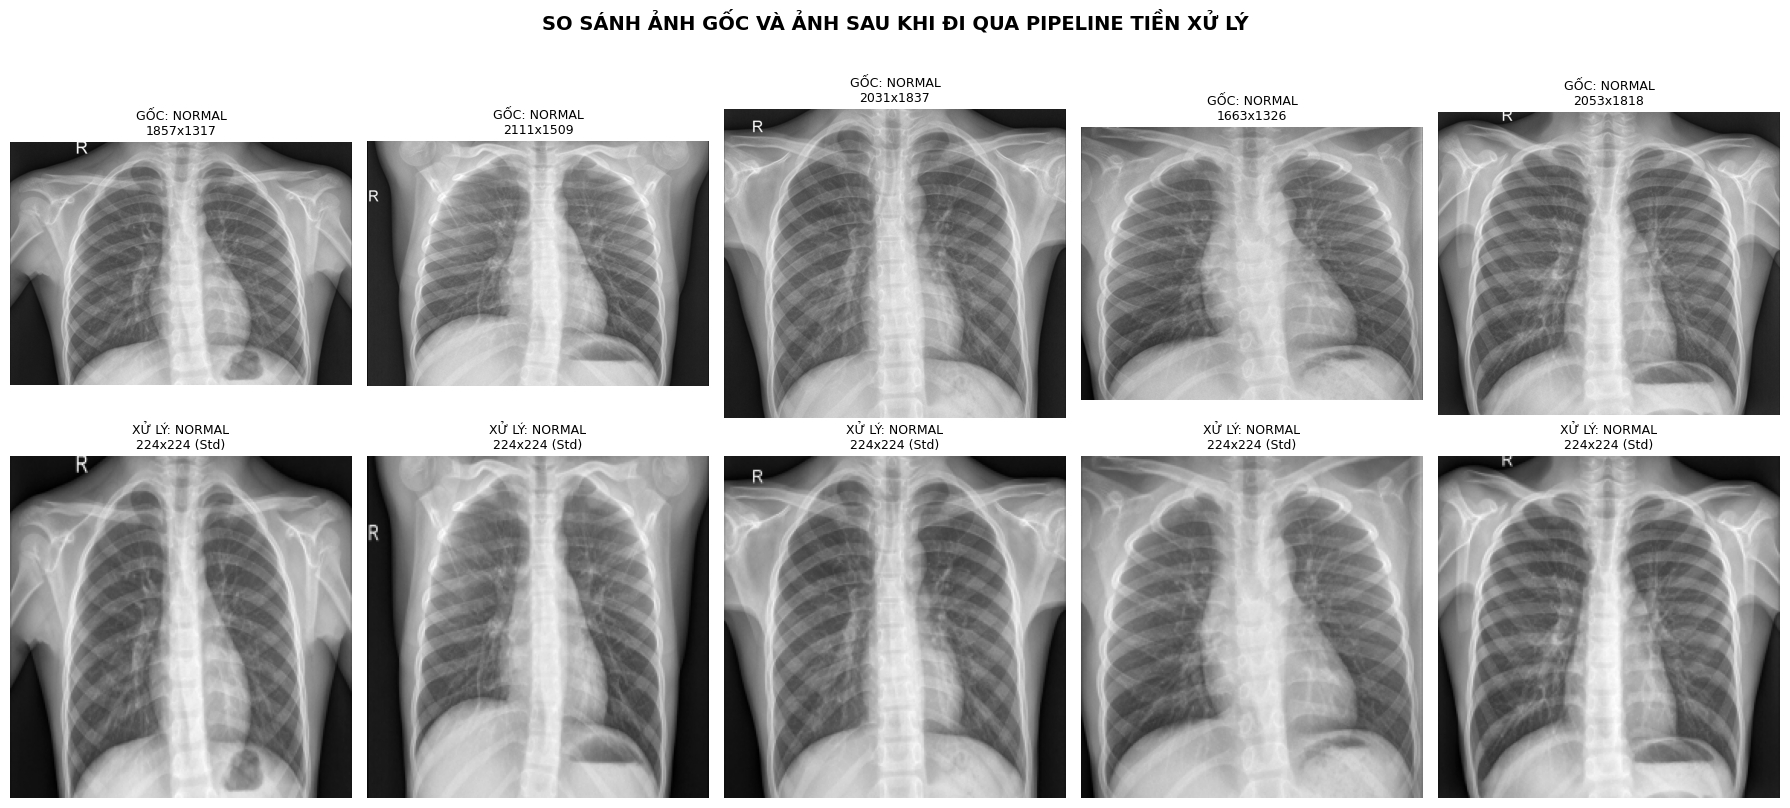

In [12]:
import matplotlib.pyplot as plt

num_samples = len(sample_list)
if num_samples > 0:
    # Tạo khung hình 2 hàng, num_samples cột
    fig, axes = plt.subplots(2, num_samples, figsize=(18, 8))
    
    for i, item in enumerate(sample_list):
        # ẢNH GỐC
        # Chuyển BGR sang RGB để hiển thị đúng màu
        orig_rgb = cv2.cvtColor(item['orig_img'], cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(orig_rgb)
        axes[0, i].set_title(f"GỐC: {item['cat']}\n{item['orig_img'].shape[1]}x{item['orig_img'].shape[0]}", fontsize=9)
        axes[0, i].axis('off')
        
        # ẢNH ĐÃ XỬ LÝ (Standardized)
        axes[1, i].imshow(item['proc_img'], cmap='gray')
        axes[1, i].set_title(f"XỬ LÝ: {item['cat']}\n224x224 (Std)", fontsize=9)
        axes[1, i].axis('off')
    
    plt.suptitle("SO SÁNH ẢNH GỐC VÀ ẢNH SAU KHI ĐI QUA PIPELINE TIỀN XỬ LÝ", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

**Insights:** 
* Mặc dù ảnh đã xử lý (hàng dưới) trông có vẻ rõ hơn một chút về độ tương phản do phân phối lại giá trị pixel, nhưng các chi tiết giải phẫu như xương sườn và vùng phổi vẫn hoàn toàn khớp với ảnh gốc. 
* Điều này khẳng định Pipeline tiền xử lý của nhóm đạt yêu cầu: **Tối ưu về mặt toán học nhưng vẫn bảo toàn trọn vẹn thông tin y khoa.**